#Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

* много записей без указания просмотров (новые лоты либо статиситка по ним не ведется) - число просмотров заменил нулями;
* neighbourhood больше 200 районов - плохой кандидат на onehot;
* цена не всегда указана (равна нулю); такие записи удалил;
* присутствуют эксклюзивные лоты (цена очень высока); попробовал удалять такие записи - результат лучше;
* основаня аренда - краткосрочная (минимальный срок аренды менее месяца); попробовал удалять длительную аренду - результат лучше;
* очень большой дисбаланс neighbourhood_group (большое число Brooklyn и Manhattan) и room_type (недостаточное число Shared Room); можно попробовать выровнять выборку (в ущерб количеству) - не пробовал;
* удалил поля neighbourhood_group и number_of_reviews как имеющие высокую корреляцию с другими полями и низкой корреляцией с price  - результат лучше;
* пересчет координат в расстояние от Манхэттэна результат не улучшил;
* заменил neighbourhood, на среднюю цену по району - результат лучше;
* комбинирование методов позволило снизить ошибку с "mape:0.630, rmse:184.601, r2:0.108" до "mape:0.442, rmse:95.715, r2:0.341" (LassoCV), что по-прежнему очень много


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, mean_squared_log_error, r2_score)

from geopy.distance import geodesic

# Загрузка и предобработка данных

In [2]:
dataset_rent = pd.read_csv("HW10(lesson41)_data.csv")

In [3]:
# удаляем неинформативные столбцы
def drop_feaches(dataset):
    drop_feaches_lst = ["id", "name", "host_id", "host_name", "last_review"]
    dataset.drop(drop_feaches_lst, axis="columns", inplace=True)

# заполняем null
def fill_null(dataset):
    # если просмотры не указаны считаем что их не было
    dataset["reviews_per_month"] = dataset["reviews_per_month"].fillna(0)

# удаляем некорректные записи
def drop_invalid_records(dataset):
    # цена равна нулю
    dataset.drop(dataset[dataset["price"] == 0].index, axis="index", inplace=True)

# удаляем неудобные записи
def drop_unusual_records(dataset):
    # эксклюзивный лот
    dataset.drop(dataset[dataset["price"] > 1000].index, axis="index", inplace=True)
    # длительная аренда
    dataset.drop(dataset[dataset["minimum_nights"] > 45].index, axis="index", inplace=True)

# Разведочный анализ данных

In [4]:
dataset_rent.head(3).T

,0,1,2
id,2539,2595,3647
name,Clean & quiet apt home by the park,Skylit Midtown Castle,THE VILLAGE OF HARLEM....NEW YORK !
host_id,2787,2845,4632
host_name,John,Jennifer,Elisabeth
neighbourhood_group,Brooklyn,Manhattan,Manhattan
neighbourhood,Kensington,Midtown,Harlem
latitude,40.64749,40.75362,40.80902
longitude,-73.97237,-73.98377,-73.9419
room_type,Private room,Entire home/apt,Private room
price,149,225,150


In [5]:
dataset_rent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
dataset_rent.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [7]:
# прочие поля с пропусками мы удалим, а reviews_per_month необходимо заполнить
fill_null(dataset_rent)

In [8]:
# удаляем неинформативные поля
drop_feaches(dataset_rent)
# проверяем что получилось
dataset_rent.head(3).T

,0,1,2
neighbourhood_group,Brooklyn,Manhattan,Manhattan
neighbourhood,Kensington,Midtown,Harlem
latitude,40.64749,40.75362,40.80902
longitude,-73.97237,-73.98377,-73.9419
room_type,Private room,Entire home/apt,Private room
price,149,225,150
minimum_nights,1,1,3
number_of_reviews,9,45,0
reviews_per_month,0.21,0.38,0.0
calculated_host_listings_count,6,2,1


In [9]:
for col in dataset_rent.select_dtypes(include=['object']).columns:
    print(f"{col}: {dataset_rent[col].unique().shape[0]}")

neighbourhood_group: 5
neighbourhood: 221
room_type: 3


OneHot для neighbourhood не лучшая идея

In [10]:
dataset_rent.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,48895.0,40.728949,0.054530,40.49979,40.69010,40.72307,40.763115,40.91306
longitude,48895.0,-73.952170,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
price,48895.0,152.720687,240.154170,0.00000,69.00000,106.00000,175.000000,10000.00000
minimum_nights,48895.0,7.029962,20.510550,1.00000,1.00000,3.00000,5.000000,1250.00000
number_of_reviews,48895.0,23.274466,44.550582,0.00000,1.00000,5.00000,24.000000,629.00000
reviews_per_month,48895.0,1.090910,1.597283,0.00000,0.04000,0.37000,1.580000,58.50000
calculated_host_listings_count,48895.0,7.143982,32.952519,1.00000,1.00000,1.00000,2.000000,327.00000
availability_365,48895.0,112.781327,131.622289,0.00000,0.00000,45.00000,227.000000,365.00000


цена не всегда указана (равна нулю). такие записи необходимо удалить сразу.

присутствуют эксклюзивные лоты (цена очень высока). такие записи удаляем при обучении.

основаня аренда - краткосрочная (минимальный срок аренды менее месяца). длительную аренду тоже можно попробовать удалить при обучении.

In [11]:
drop_invalid_records(dataset_rent)

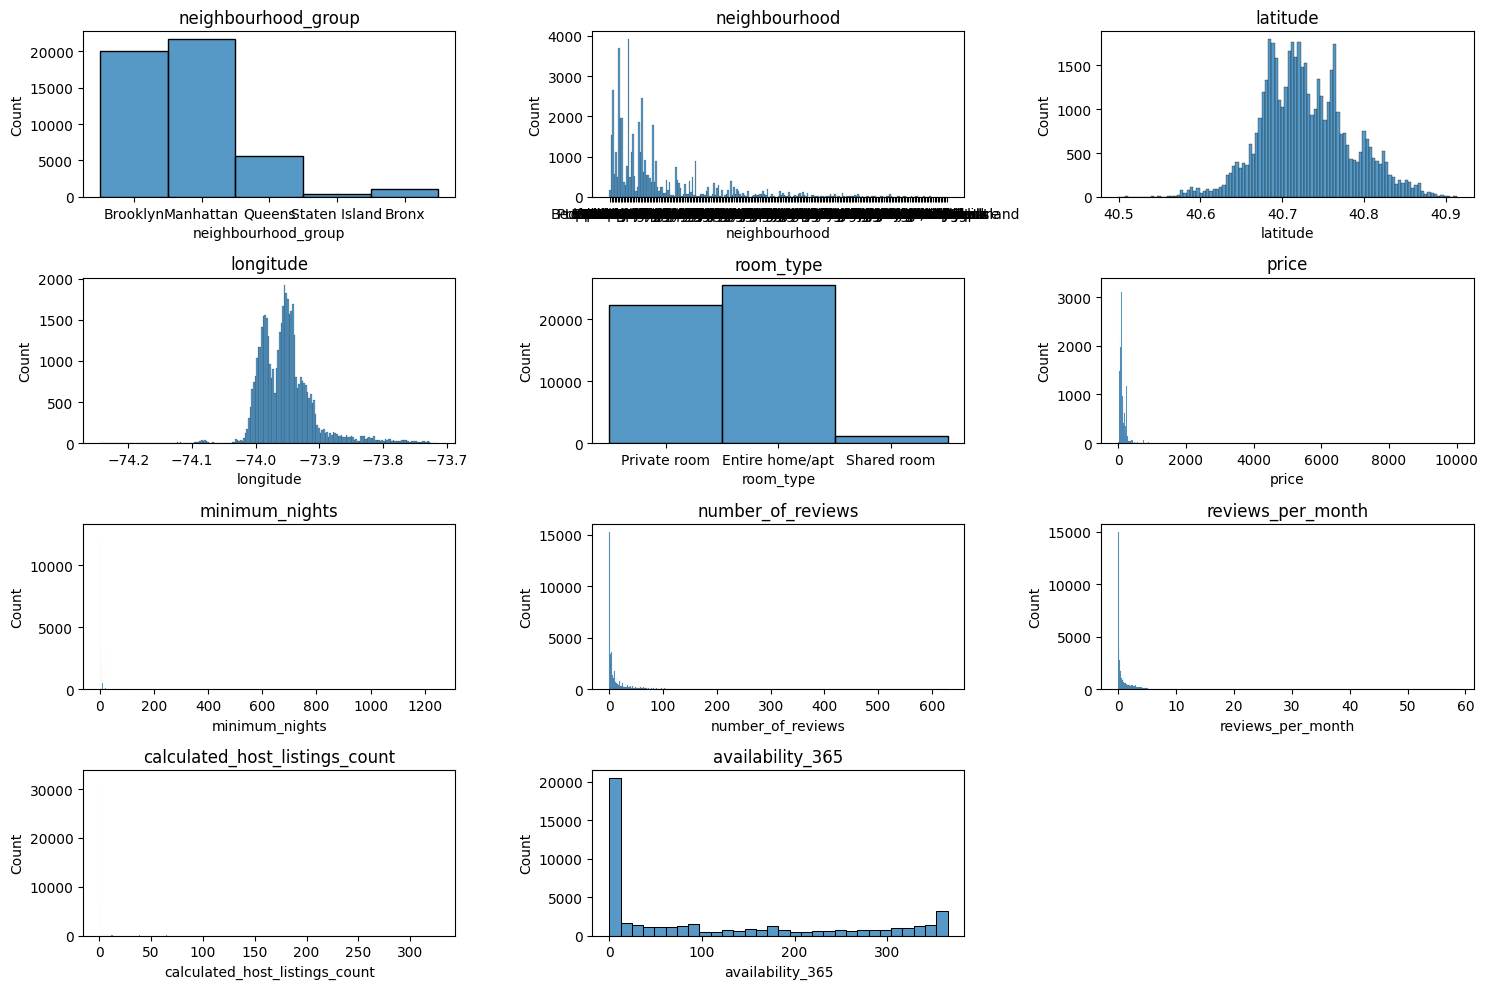

In [12]:
features_lst = dataset_rent.columns.to_list()

plt_col_count = 3
plt_row_count = 1 + int(len(features_lst) / plt_col_count)
fig, axes = plt.subplots(plt_row_count, plt_col_count, figsize=(15, 10))
axes_iter = axes.flat
for field, axis in zip(features_lst, axes_iter):
    # sns.countplot(data = dataset_croc, x = field, ax = axis)
    sns.histplot(dataset_rent, x = field,
                 element = "bars", stat = "count", ax = axis, legend = False)
    axis.set_title(field)
# удаляем незадействованные оси
for axis in axes_iter:
    fig.delaxes(axis)

# графики мы подписали, теперь нужно место для title
plt.tight_layout()
plt.show()

очень большой дисбаланс neighbourhood_group (большое число Brooklyn и Manhattan) и room_type (недостаточное число Shared Room)

In [13]:
le = LabelEncoder()
dataset_label = dataset_rent.copy()
for col in dataset_label.select_dtypes(include=['object']).columns:
    dataset_label[col] = le.fit_transform(dataset_label[col])

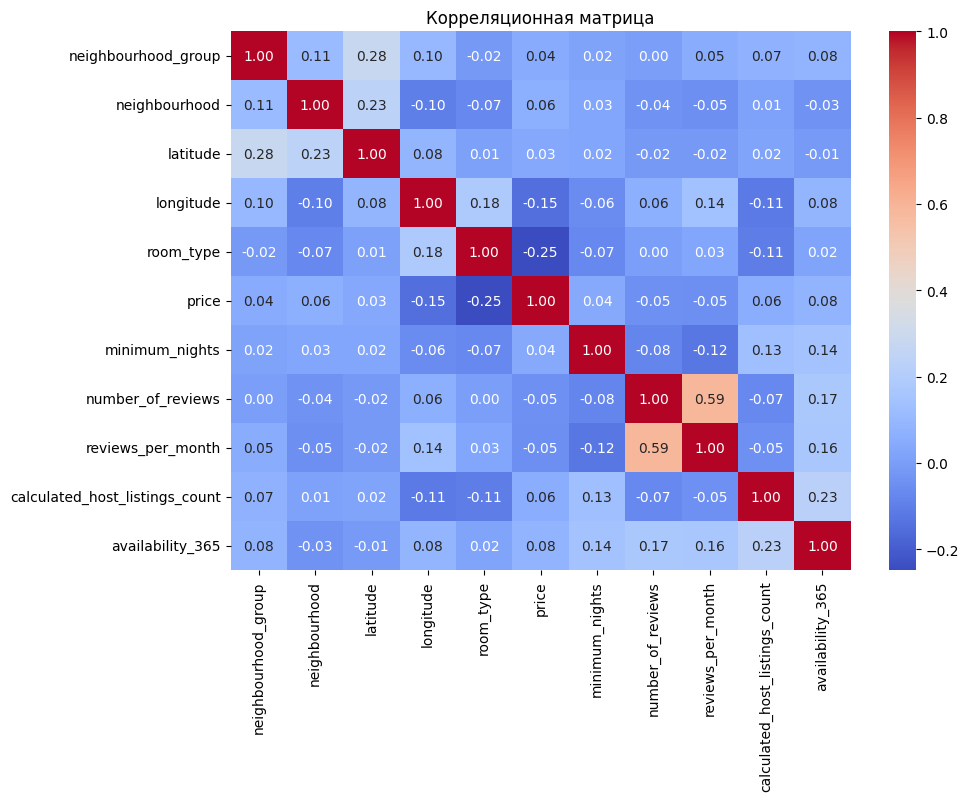

In [14]:
dataset_rent_corr = dataset_label.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(dataset_rent_corr, fmt= ".2f", annot = True, cmap = "coolwarm")
plt.title("Корреляционная матрица")
plt.show()

# Моделирование

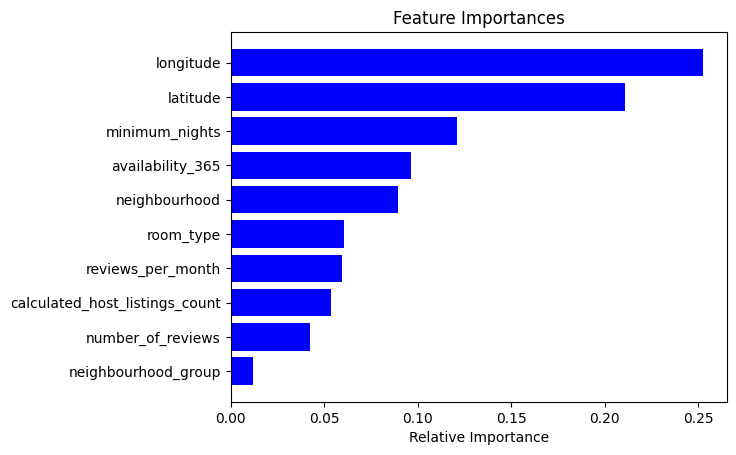

In [15]:
features = dataset_rent.drop("price", axis = "columns").copy()
target = dataset_rent["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.3, random_state = 42)

encoder = OrdinalEncoder(handle_unknown = "use_encoded_value", unknown_value = -1)
X_train["room_type"] = encoder.fit_transform(X_train[["room_type"]])
X_test["room_type"] = encoder.transform(X_test[["room_type"]])
X_train["neighbourhood"] = encoder.fit_transform(X_train[["neighbourhood"]])
X_test["neighbourhood"] = encoder.transform(X_test[["neighbourhood"]])
X_train["neighbourhood_group"] = encoder.fit_transform(X_train[["neighbourhood_group"]])
X_test["neighbourhood_group"] = encoder.transform(X_test[["neighbourhood_group"]])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestRegressor()
model.fit(X_train, y_train)
model_accuracy = model.score(X_test, y_test)
# print(model_accuracy)

features_lst = features.columns.to_list()
importances = model.feature_importances_
indices = np.argsort(importances)

plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features_lst[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()


In [16]:
def model_on_dataset(dataset, target, categorical_encoder, numerical_scaler, model):
    features_dataset = dataset.drop(target, axis = "columns").copy()
    target_dataset = dataset[target].copy()
    X_train, X_test, y_train, y_test = train_test_split(features_dataset, target_dataset, test_size = 0.3, random_state = 42)

    categorical_features = features_dataset.select_dtypes(include = ["object"]).columns.to_list()
    for cat_feature in categorical_features:
        X_train[cat_feature] = categorical_encoder.fit_transform(X_train[[cat_feature]])
        X_test[cat_feature] = categorical_encoder.transform(X_test[[cat_feature]])

    numerical_features = features_dataset.select_dtypes(include=np.number).columns.tolist()
    for num_feature in numerical_features:
        X_train[cat_feature] = numerical_scaler.fit_transform(X_train[[cat_feature]])
        X_test[cat_feature] = numerical_scaler.transform(X_test[[cat_feature]])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    score_r2 = r2_score(y_test, y_pred)
    return f"mape:{mape:.3f}, rmse:{rmse:.3f}, r2:{score_r2:.3f}"

In [17]:
def calc_models(dataset, target, categorical_encoders, numerical_scalers, models):
    result_dict = {}
    for encoder_name, encoder in categorical_encoders.items():
        for scaler_name, scaler in numerical_scalers.items():
            preprocessor_info = f"{encoder_name} - {scaler_name}"
            result_dict[preprocessor_info] = {}
            for model_name, model in models.items():
                result_dict[preprocessor_info][model_name] = model_on_dataset(dataset, target, encoder, scaler, model)
    return pd.DataFrame(result_dict)

In [18]:
categorical_encoders = {
    "OrdinalEncoder": OrdinalEncoder(handle_unknown = "use_encoded_value", unknown_value = -1),
}
numerical_scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}
models = {
    "KNeighborsRegressor": KNeighborsRegressor(),
    "LogisticRegression": LogisticRegression(),
    "LassoCV": LassoCV(),
    "RidgeCV": RidgeCV(),
    "ElasticNetCV": ElasticNetCV(),
}

In [19]:
rent_stat = calc_models(dataset_rent, "price", categorical_encoders, numerical_scalers, models)
rent_stat.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,OrdinalEncoder - StandardScaler,OrdinalEncoder - RobustScaler
KNeighborsRegressor,"mape:0.723, rmse:212.632, r2:-0.184","mape:0.742, rmse:210.544, r2:-0.161"
LogisticRegression,"mape:0.507, rmse:195.874, r2:-0.005","mape:0.629, rmse:196.807, r2:-0.014"
LassoCV,"mape:0.630, rmse:184.601, r2:0.108","mape:0.633, rmse:184.623, r2:0.107"
RidgeCV,"mape:0.599, rmse:182.994, r2:0.123","mape:0.599, rmse:182.994, r2:0.123"
ElasticNetCV,"mape:0.782, rmse:189.354, r2:0.061","mape:0.841, rmse:191.809, r2:0.037"


In [20]:
dataset_short = dataset_rent.copy()
drop_unusual_records(dataset_short)

short_stat = calc_models(dataset_short, "price", categorical_encoders, numerical_scalers, models)
short_stat.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,OrdinalEncoder - StandardScaler,OrdinalEncoder - RobustScaler
KNeighborsRegressor,"mape:0.634, rmse:111.569, r2:0.105","mape:0.656, rmse:112.904, r2:0.083"
LogisticRegression,"mape:0.498, rmse:114.050, r2:0.065","mape:0.633, rmse:118.150, r2:-0.004"
LassoCV,"mape:0.528, rmse:102.183, r2:0.249","mape:0.529, rmse:102.210, r2:0.249"
RidgeCV,"mape:0.496, rmse:99.461, r2:0.289","mape:0.496, rmse:99.461, r2:0.289"
ElasticNetCV,"mape:0.652, rmse:108.094, r2:0.160","mape:0.722, rmse:112.201, r2:0.095"


In [21]:
manhattan_mean = dataset_rent[dataset_rent["neighbourhood_group"] == "Manhattan"][["latitude", "longitude"]].mean()
def distance_from_manhattan(latitude, longitude):
    return geodesic((manhattan_mean["latitude"], manhattan_mean["longitude"]), (latitude, longitude)).meters

dataset_dist = dataset_rent.copy()
dataset_dist["distance_from_manhattan"] = dataset_dist.apply(lambda x:distance_from_manhattan(x["latitude"], x["longitude"]), axis = "columns")
dataset_dist.drop(["latitude", "longitude"], axis="columns", inplace=True)

dist_stat = calc_models(dataset_dist, "price", categorical_encoders, numerical_scalers, models)
dist_stat.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,OrdinalEncoder - StandardScaler,OrdinalEncoder - RobustScaler
KNeighborsRegressor,"mape:0.741, rmse:206.743, r2:-0.119","mape:0.742, rmse:206.796, r2:-0.120"
LogisticRegression,"mape:0.567, rmse:197.761, r2:-0.024","mape:0.573, rmse:197.799, r2:-0.025"
LassoCV,"mape:0.794, rmse:190.650, r2:0.048","mape:0.794, rmse:190.650, r2:0.048"
RidgeCV,"mape:0.586, rmse:182.880, r2:0.124","mape:0.586, rmse:182.880, r2:0.124"
ElasticNetCV,"mape:0.794, rmse:190.667, r2:0.048","mape:0.794, rmse:190.667, r2:0.048"


In [22]:
dataset_tight = dataset_rent.copy()
drop_feaches_lst = ["neighbourhood_group", "number_of_reviews"]
dataset_tight.drop(drop_feaches_lst, axis="columns", inplace=True)

tight_stat = calc_models(dataset_tight, "price", categorical_encoders, numerical_scalers, models)
tight_stat.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,OrdinalEncoder - StandardScaler,OrdinalEncoder - RobustScaler
KNeighborsRegressor,"mape:0.667, rmse:207.215, r2:-0.124","mape:0.701, rmse:208.803, r2:-0.142"
LogisticRegression,"mape:0.526, rmse:196.693, r2:-0.013","mape:0.627, rmse:198.441, r2:-0.031"
LassoCV,"mape:0.625, rmse:184.849, r2:0.105","mape:0.628, rmse:184.872, r2:0.105"
RidgeCV,"mape:0.602, rmse:183.322, r2:0.120","mape:0.602, rmse:183.322, r2:0.120"
ElasticNetCV,"mape:0.777, rmse:189.598, r2:0.059","mape:0.836, rmse:192.031, r2:0.034"


In [23]:
dataset_mean = dataset_rent.copy()

neighbourhood_price_map = dataset_mean.groupby("neighbourhood")["price"].median().to_dict()
dataset_mean["neighbourhood_median"] = dataset_mean["neighbourhood"].map(neighbourhood_price_map)
dataset_mean.drop(["neighbourhood"], axis="columns", inplace=True)

mean_stat = calc_models(dataset_mean, "price", categorical_encoders, numerical_scalers, models)
mean_stat.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,OrdinalEncoder - StandardScaler,OrdinalEncoder - RobustScaler
KNeighborsRegressor,"mape:0.616, rmse:205.644, r2:-0.107","mape:0.639, rmse:204.847, r2:-0.099"
LogisticRegression,"mape:0.426, rmse:191.595, r2:0.039","mape:0.448, rmse:192.103, r2:0.034"
LassoCV,"mape:0.530, rmse:180.336, r2:0.148","mape:0.530, rmse:180.388, r2:0.148"
RidgeCV,"mape:0.532, rmse:180.318, r2:0.149","mape:0.532, rmse:180.318, r2:0.149"
ElasticNetCV,"mape:0.617, rmse:183.767, r2:0.116","mape:0.654, rmse:185.221, r2:0.102"


In [24]:
dataset_result = dataset_rent.copy()
drop_unusual_records(dataset_result)

neighbourhood_price_map = dataset_result.groupby("neighbourhood")["price"].median().to_dict()
dataset_result["neighbourhood_median"] = dataset_result["neighbourhood"].map(neighbourhood_price_map)

drop_feaches_lst = ["neighbourhood_group", "neighbourhood", "number_of_reviews"]
dataset_result.drop(drop_feaches_lst, axis="columns", inplace=True)

result_stat = calc_models(dataset_result, "price", categorical_encoders, numerical_scalers, models)
result_stat.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,OrdinalEncoder - StandardScaler,OrdinalEncoder - RobustScaler
KNeighborsRegressor,"mape:0.497, rmse:102.325, r2:0.247","mape:0.532, rmse:104.712, r2:0.211"
LogisticRegression,"mape:0.420, rmse:110.262, r2:0.126","mape:0.434, rmse:111.905, r2:0.099"
LassoCV,"mape:0.442, rmse:95.715, r2:0.341","mape:0.442, rmse:95.769, r2:0.340"
RidgeCV,"mape:0.446, rmse:95.682, r2:0.342","mape:0.446, rmse:95.682, r2:0.342"
ElasticNetCV,"mape:0.520, rmse:100.664, r2:0.271","mape:0.563, rmse:103.185, r2:0.234"
